In [1]:
import re
import pandas as pd 
import torch
import numpy as np

from sbi_for_diffusion_models.models.rt_choice_model import (
    max_num_pulses,
    pack_x_rt_choice,
    mask_unperceived_pulses,
)
from sbi_for_diffusion_models.run_config import PULSE_INTERVAL
from sbi_for_diffusion_models.data_simulator import flatten_observed_session

In [2]:
data = pd.read_csv(r"c:\Users\senne\Documents\GitHub\marmoset\data\marmoset_data.csv.gz", compression="gzip")
ayla_60_40 = data[(data["name"] == "Aayla") & (data["stage"] == "60-40")]

In [41]:
ayla_60_40

,name,specie,group,stage,sex,session_datetime,trial_datetime,trial,choice,outcome,rt,correct_side,flashes_left,flashes_right,numflashleft,numflashright,probflashleft,probflashright,flash_bins,init_time
6284,Aayla,Marmoset,WT,60-40,F,20-May-2024-11-10-09,2024-05-20 11:10:41,6285,left,correct,2.376066,left,1111100101000010001101011110001101011001,0000011010111101110010100001110010100110,21,19,NaN,NaN,8.0,15.477867
6285,Aayla,Marmoset,WT,60-40,F,20-May-2024-11-10-09,2024-05-20 11:10:54,6286,left,error,0.919298,right,1100110100100010011001111001101010101011,0011001011011101100110000110010101010100,21,19,NaN,NaN,3.0,7.649148
6286,Aayla,Marmoset,WT,60-40,F,20-May-2024-11-10-09,2024-05-20 11:10:59,6287,left,error,1.595711,right,0100101100011110110101000101010001000100,1011010011100001001010111010101110111011,17,23,NaN,NaN,5.0,0.995937
6287,Aayla,Marmoset,WT,60-40,F,20-May-2024-11-10-09,2024-05-20 11:11:04,6288,right,error,2.244801,left,0110100010111111110011101110010101011011,1001011101000000001100010001101010100100,25,15,NaN,NaN,7.0,0.714478
6288,Aayla,Marmoset,WT,60-40,F,20-May-2024-11-10-09,2024-05-20 11:11:11,6289,right,correct,2.309789,right,0000010010100000010010100111111111110100,1111101101011111101101011000000000001011,18,22,NaN,NaN,8.0,1.230056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9272,Aayla,Marmoset,WT,60-40,F,27-May-2024-09-41-29,2024-05-27 11:19:29,9273,left,correct,1.807373,left,0111100110011010111101110000110000110011,1000011001100101000010001111001111001100,22,18,NaN,NaN,6.0,398.620962
9273,Aayla,Marmoset,WT,60-40,F,27-May-2024-09-41-29,2024-05-27 11:19:44,9274,left,error,1.951449,right,0101000101010001000001100101110110001000,1010111010101110111110011010001001110111,15,25,NaN,NaN,6.0,10.278110
9274,Aayla,Marmoset,WT,60-40,F,27-May-2024-09-41-29,2024-05-27 11:19:50,9275,right,correct,1.858922,right,1001001000011011000010000001011011010100,0110110111100100111101111110100100101011,15,25,NaN,NaN,6.0,0.313276
9275,Aayla,Marmoset,WT,60-40,F,27-May-2024-09-41-29,2024-05-27 11:19:58,9276,right,correct,1.204457,right,1000100001011000101010001010001100001110,0111011110100111010101110101110011110001,15,25,NaN,NaN,4.0,3.229653


In [3]:
def _parse_bitstring_to_pulses(s: str, P: int) -> np.ndarray:
    """
    Parse a '0/1' string into length-P array.
    Accepts strings like: "0101", "0 1 0 1", "0,1,0,1".
    Pads with 0s or truncates to length P.
    """
    if s is None or (isinstance(s, float) and np.isnan(s)):
        bits = []
    else:
        bits = re.findall(r"[01]", str(s))
    arr = np.zeros(P, dtype=np.float32)
    n = min(P, len(bits))
    if n > 0:
        arr[:n] = np.asarray(bits[:n], dtype=np.float32)
    return arr


def package_df_for_npe(
    df,
    *,
    cfg=None,                       # optional: to get NUM_TRIALS_OBS, LOG_RT_MANUALLY
    choice_col="choice",
    rt_col="rt",
    pulses_col="flashes_right",
    T: int | None = None,           # override number of trials used in training
    log_rt: bool | None = None,     # override log transform
    device: str | torch.device = "cpu",
):
    """
    Returns:
      x_o_flat: (1, T*(2+P+1)) float32 tensor (mask included per trial)
      (x_o, pulses_o, mask_o): per-trial tensors for debugging
    """
    dev = torch.device(device)

    # Training-time shapes must match at inference-time.
    if T is None:
        if cfg is None:
            raise ValueError("Provide T=... or pass cfg with NUM_TRIALS_OBS.")
        T = int(cfg.NUM_TRIALS_OBS)

    if log_rt is None:
        log_rt = bool(getattr(cfg, "LOG_RT_MANUALLY", False)) if cfg is not None else False

    P = int(max_num_pulses())
    trial_dim = 2 + P + 1

    # Allocate per-trial arrays, default masked-out (padding)
    rts = np.zeros(T, dtype=np.float32)
    choices = np.zeros(T, dtype=np.float32)
    pulses = np.zeros((T, P), dtype=np.float32)
    mask = np.zeros((T, 1), dtype=np.float32)

    n = min(T, len(df))
    if n > 0:

        # --- choice mapping (robust to NaN / non-strings) ---
        ch_series = (
            df[choice_col]
            .astype("string")          # pandas StringDtype (safe)
            .str.strip()
            .str.lower()
        )

        # right->1, left->0, otherwise NaN
        ch = np.full(n, np.nan, dtype=np.float32)
        is_right = ch_series.iloc[:n].eq("right").to_numpy()
        is_left  = ch_series.iloc[:n].eq("left").to_numpy()

        ch[is_right] = 1.0
        ch[is_left]  = 0.0

        # --- rt ---
        rt = pd.to_numeric(df[rt_col].iloc[:n], errors="coerce").astype(np.float32).values

        # valid trial = finite rt and valid choice
        valid = np.isfinite(rt) & np.isfinite(ch)

        rts[:n] = np.where(np.isfinite(rt), rt, 0.0)
        choices[:n] = np.where(np.isfinite(ch), ch, 0.0)
        mask[:n, 0] = valid.astype(np.float32)

        # --- pulses ---
        pulse_strs = df[pulses_col].iloc[:n].values
        for i in range(n):
            pulses[i] = _parse_bitstring_to_pulses(pulse_strs[i], P)

    # Build tensors
    rt_choice = torch.tensor(np.stack([rts, choices], axis=1), device=dev, dtype=torch.float32)  # (T,2)
    mask_o = torch.tensor(mask, device=dev, dtype=torch.float32)                                 # (T,1)
    pulses_o = torch.tensor(pulses, device=dev, dtype=torch.float32)                             # (T,P)

    # Pack [rt, choice] exactly like training does (optional log-RT) :contentReference[oaicite:2]{index=2}
    x_o = pack_x_rt_choice(rt_choice, log_rt=bool(log_rt)).view(T, 2)
    x_o = x_o * mask_o  # zero-out invalid trials

    # Mask out pulses that occurred after the decision time (same idea as training) :contentReference[oaicite:3]{index=3}
    pulses_masked = mask_unperceived_pulses(pulses_o, rt_choice[:, 0], float(PULSE_INTERVAL))
    pulses_masked = torch.nan_to_num(pulses_masked, nan=0.0) * mask_o

    # Flatten to the exact conditioning vector expected by NPE :contentReference[oaicite:4]{index=4}
    x_o_flat = flatten_observed_session(x_o, pulses_masked, mask_o)  # (1, T*(2+P+1))
    assert x_o_flat.shape == (1, T * trial_dim), (x_o_flat.shape, T, trial_dim)

    return x_o_flat, (x_o, pulses_masked, mask_o)

In [4]:
from __future__ import annotations

import os
import re
import numpy as np
import pandas as pd
import torch

torch.distributions.Distribution.set_default_validate_args(False)

from sbi.inference import NPE
from sbi.neural_nets import posterior_nn

from sbi_for_diffusion_models.priors import build_prior_theta
from sbi_for_diffusion_models.mnpe import run_inference_npe
from sbi_for_diffusion_models.models.rt_choice_model import (
    max_num_pulses,
    pack_x_rt_choice,
    mask_unperceived_pulses,
)
from sbi_for_diffusion_models.Embeddings import MaskAwarePermutationInvariantEmbedding
from sbi_for_diffusion_models.data_simulator import flatten_observed_session
from sbi_for_diffusion_models.run_config import RUN_CONFIG_PARAMS as cfg, PULSE_INTERVAL


def load_npe(model_path: str, device: str = "cpu"):
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    saved_cfg = checkpoint["config"]

    P = max_num_pulses()
    T = int(saved_cfg.NUM_TRIALS_OBS)
    trial_dim = 2 + P + 1
    theta_dim = 5
    x_dim = T * trial_dim

    embedding_net = MaskAwarePermutationInvariantEmbedding(
        num_trials=T,
        trial_dim=trial_dim,
        trial_net_hidden=int(saved_cfg.NPE_TRIAL_NET_HIDDEN),
        trial_net_layers=int(saved_cfg.NPE_TRIAL_NET_LAYERS),
        trial_net_output_dim=int(saved_cfg.NPE_TRIAL_NET_OUTPUT_DIM),
        post_agg_hidden=int(saved_cfg.NPE_POST_AGG_HIDDEN),
        post_agg_layers=int(saved_cfg.NPE_POST_AGG_LAYERS),
        output_dim=int(saved_cfg.NPE_EMBEDDING_OUTPUT_DIM),
        aggregation=str(saved_cfg.NPE_AGG_FN),
    )

    est_builder = posterior_nn(
        model="nsf",
        z_score_theta="independent",
        z_score_x="none",
        hidden_features=int(saved_cfg.NPE_HIDDEN_FEATURES),
        num_transforms=int(saved_cfg.NPE_NUM_TRANSFORMS),
        num_bins=int(saved_cfg.NPE_NUM_BINS),
        embedding_net=embedding_net,
    )

    dummy_theta = torch.randn(2, theta_dim, device=device)
    dummy_x = torch.randn(2, x_dim, device=device)
    density_estimator = est_builder(dummy_theta, dummy_x)

    density_estimator.load_state_dict(checkpoint["state_dict"], strict=True)
    density_estimator.to(device)
    density_estimator.eval()
    return density_estimator, saved_cfg


def _parse_bitstring_to_pulses(s: str, P: int) -> np.ndarray:
    if s is None or (isinstance(s, float) and np.isnan(s)):
        bits = []
    else:
        bits = re.findall(r"[01]", str(s))
    arr = np.zeros(P, dtype=np.float32)
    n = min(P, len(bits))
    if n > 0:
        arr[:n] = np.asarray(bits[:n], dtype=np.float32)
    return arr


def package_df_for_npe(
    df: pd.DataFrame,
    *,
    T: int,
    log_rt: bool,
    choice_col: str = "choice",
    rt_col: str = "rt",
    pulses_col: str = "flashes_right",
    device: str | torch.device = "cpu",
):
    dev = torch.device(device)
    P = int(max_num_pulses())
    trial_dim = 2 + P + 1

    rts = np.zeros(T, dtype=np.float32)
    choices = np.zeros(T, dtype=np.float32)
    pulses = np.zeros((T, P), dtype=np.float32)
    mask = np.zeros((T, 1), dtype=np.float32)

    n = min(T, len(df))
    if n > 0:
        ch_series = df[choice_col].astype("string").str.strip().str.lower()
        # exact match; swap to .str.contains("right", na=False) if needed
        is_right = ch_series.iloc[:n].eq("right").to_numpy()
        is_left  = ch_series.iloc[:n].eq("left").to_numpy()

        ch = np.full(n, np.nan, dtype=np.float32)
        ch[is_right] = 1.0
        ch[is_left]  = 0.0

        rt = pd.to_numeric(df[rt_col].iloc[:n], errors="coerce").astype(np.float32).to_numpy()
        valid = np.isfinite(rt) & np.isfinite(ch)

        rts[:n] = np.where(np.isfinite(rt), rt, 0.0)
        choices[:n] = np.where(np.isfinite(ch), ch, 0.0)
        mask[:n, 0] = valid.astype(np.float32)

        pulse_strs = df[pulses_col].iloc[:n].to_numpy()
        for i in range(n):
            pulses[i] = _parse_bitstring_to_pulses(pulse_strs[i], P)

    rt_choice = torch.tensor(np.stack([rts, choices], axis=1), device=dev, dtype=torch.float32)  # (T,2)
    mask_o = torch.tensor(mask, device=dev, dtype=torch.float32)                                  # (T,1)
    pulses_o = torch.tensor(pulses, device=dev, dtype=torch.float32)                              # (T,P)

    x_o = pack_x_rt_choice(rt_choice, log_rt=bool(log_rt)).view(T, 2)
    x_o = x_o * mask_o

    pulses_masked = mask_unperceived_pulses(pulses_o, rt_choice[:, 0], float(PULSE_INTERVAL))
    pulses_masked = torch.nan_to_num(pulses_masked, nan=0.0) * mask_o

    x_o_flat = flatten_observed_session(x_o, pulses_masked, mask_o)
    assert x_o_flat.shape[0] == 1
    assert x_o_flat.shape[1] == T * trial_dim, (x_o_flat.shape, T, trial_dim)
    return x_o_flat, (x_o, pulses_masked, mask_o)

def infer_from_real_df(df_real: pd.DataFrame, *, model_path: str, device: str = "cpu"):
    dev = torch.device(device)

    density_estimator, saved_cfg = load_npe(model_path, device=device)

    prior_theta = build_prior_theta()
    if hasattr(prior_theta, "to"):
        prior_theta.to(dev)

    inference_obj = NPE(prior=prior_theta, device=device)

    T = int(saved_cfg.NUM_TRIALS_OBS)
    x_o_flat, _debug = package_df_for_npe(
        df_real,
        T=T,
        log_rt=bool(saved_cfg.LOG_RT_MANUALLY),
        choice_col="choice",
        rt_col="rt",
        pulses_col="flashes_right",
        device=device,
    )
    x_o_flat = x_o_flat.to(dev, dtype=torch.float32)

    samples = run_inference_npe(cfg, inference_obj, density_estimator, x_o_flat, prior_theta)
    return samples, x_o_flat, saved_cfg


# ---- run it ----
MODEL_PATH = os.path.expanduser("~/models/npe_rt_choice.pt")
device = "cuda" if torch.cuda.is_available() else "cpu"

samples, x_o_flat, saved_cfg = infer_from_real_df(
    ayla_60_40,              # your df
    model_path=MODEL_PATH,
    device=device,
)

print(samples.shape)         # (cfg.NPE_POSTERIOR_SAMPLES, 5) typically

  0%|          | 0/20000 [00:00<?, ?it/s]

torch.Size([20000, 5])


c:\Users\senne\Documents\GitHub\SBI-for-Diffusion-Models\.venv\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2270.)
  outputs, _ = torch.triangular_solve(


In [6]:
x_o_flat[0][86:95]

tensor([1.5957, 0.0000, 1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000],
       device='cuda:0')

In [5]:
import torch
import numpy as np

print("Shape:", samples.shape)

means = samples.mean(dim=0)
stds  = samples.std(dim=0)

for name, m, s in zip(["a0", "lam", "v", "B", "tau"], means, stds):
    print(f"{name:>4}: mean={m:.4f}, sd={s:.4f}")

Shape: torch.Size([20000, 5])
  a0: mean=0.4953, sd=0.1179
 lam: mean=0.4417, sd=0.2320
   v: mean=1.1842, sd=0.6271
   B: mean=4.5573, sd=1.9638
 tau: mean=0.5361, sd=0.2745


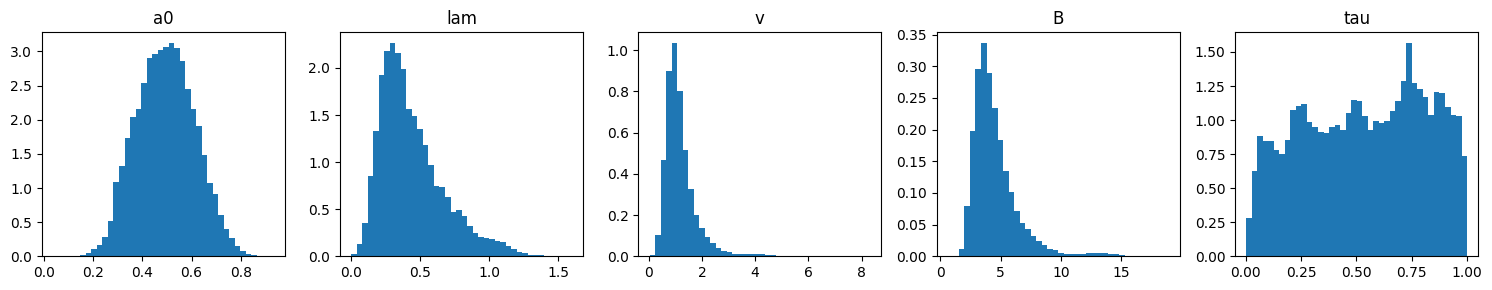

In [6]:
import matplotlib.pyplot as plt

names = ["a0", "lam", "v", "B", "tau"]

fig, axes = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    axes[i].hist(samples[:, i].numpy(), bins=40, density=True)
    axes[i].set_title(names[i])

plt.tight_layout()
plt.show()

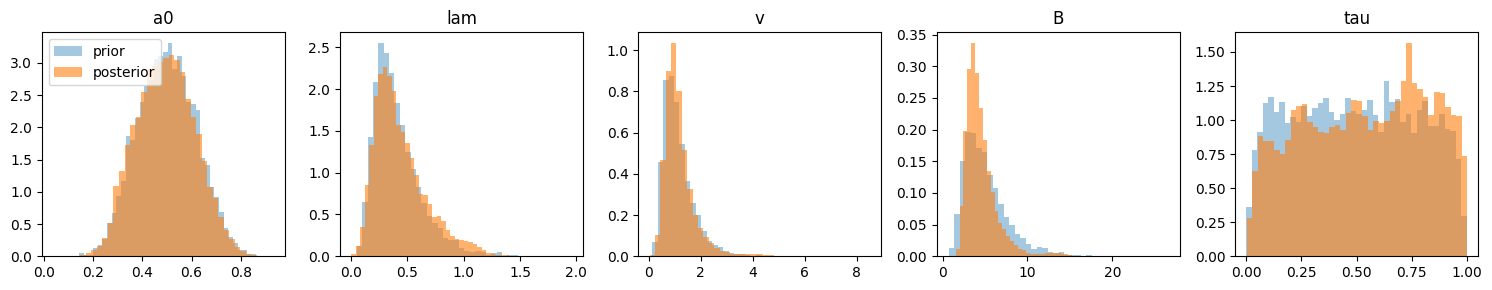

In [7]:
prior_theta = build_prior_theta()
prior_samples = prior_theta.sample((5000,)).cpu()

fig, axes = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    axes[i].hist(prior_samples[:, i], bins=40, density=True, alpha=0.4, label="prior")
    axes[i].hist(samples[:, i], bins=40, density=True, alpha=0.6, label="posterior")
    axes[i].set_title(names[i])

axes[0].legend()
plt.tight_layout()
plt.show()

In [8]:
q = torch.quantile(samples, torch.tensor([0.05, 0.5, 0.95]), dim=0)

for i, name in enumerate(names):
    lo, med, hi = q[:, i]
    print(f"{name}: 5%={lo:.3f}, 50%={med:.3f}, 95%={hi:.3f}")

a0: 5%=0.305, 50%=0.495, 95%=0.692
lam: 5%=0.157, 50%=0.387, 95%=0.912
v: 5%=0.526, 50%=1.043, 95%=2.297
B: 5%=2.505, 50%=4.091, 95%=8.067
tau: 5%=0.084, 50%=0.549, 95%=0.944


In [9]:
import torch

names = ["a0", "lam", "v", "B", "tau"]

post = samples.cpu()
prior = prior_theta.sample((post.shape[0],)).cpu()

post_mean, post_std = post.mean(0), post.std(0)
prior_mean, prior_std = prior.mean(0), prior.std(0)

print("param   post_std/prior_std   |mean shift| / prior_std")
for i, nm in enumerate(names):
    shrink = (post_std[i] / prior_std[i]).item()
    shift  = (torch.abs(post_mean[i] - prior_mean[i]) / prior_std[i]).item()
    print(f"{nm:>4}    {shrink:8.3f}             {shift:8.3f}")

param   post_std/prior_std   |mean shift| / prior_std
  a0       0.997                0.037
 lam       1.036                0.112
   v       1.029                0.079
   B       0.726                0.192
 tau       1.013                0.128


In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sbi_for_diffusion_models.data_simulator import simulate_training_sessions
from sbi_for_diffusion_models.models.rt_choice_model import max_num_pulses

def unpack_flat_session(x_flat_1d: torch.Tensor, T: int, P: int):
    """
    x_flat_1d: shape (T*(2+P+1),)
    Returns rt, choice, mask as numpy arrays of length T (mask is 0/1)
    """
    trial_dim = 2 + P + 1
    x = x_flat_1d.view(T, trial_dim)
    rt = x[:, 0]
    choice = x[:, 1]
    mask = x[:, -1]
    return rt.detach().cpu().numpy(), choice.detach().cpu().numpy(), mask.detach().cpu().numpy()

def summarize_session(rt, choice, mask):
    m = mask > 0.5
    rt_m = rt[m]
    ch_m = choice[m]
    out = {}
    out["n"] = int(m.sum())
    out["p_right"] = float(np.mean(ch_m)) if out["n"] > 0 else np.nan
    out["rt_q10"] = float(np.quantile(rt_m, 0.10)) if out["n"] > 0 else np.nan
    out["rt_q50"] = float(np.quantile(rt_m, 0.50)) if out["n"] > 0 else np.nan
    out["rt_q90"] = float(np.quantile(rt_m, 0.90)) if out["n"] > 0 else np.nan
    return out, rt_m, ch_m

def run_ppc(
    samples: torch.Tensor,
    x_o_flat: torch.Tensor,
    prior_theta,
    saved_cfg,
    *,
    n_ppc: int = 100,
    device: str = "cpu",
):
    dev = torch.device(device)
    P = int(max_num_pulses())
    T = int(saved_cfg.NUM_TRIALS_OBS)

    # --- observed summary ---
    rt_obs, ch_obs, m_obs = unpack_flat_session(x_o_flat[0], T, P)
    obs_sum, rt_obs_m, ch_obs_m = summarize_session(rt_obs, ch_obs, m_obs)

    # --- pick posterior thetas ---
    n_ppc = min(n_ppc, samples.shape[0])
    thetas = samples[:n_ppc].to(dev)

    # --- simulate posterior predictive sessions ---
    _, x_sim = simulate_training_sessions(
        prior_theta=prior_theta,
        num_sessions=n_ppc,
        num_trials=T,
        device=dev,
        mu_sensory=float(saved_cfg.MU_SENSORY),
        p_success=float(saved_cfg.P_SUCCESS),
        P=P,
        log_rt=bool(saved_cfg.LOG_RT_MANUALLY),
        theta=thetas,
        sim_batch_size=n_ppc,
    )
    x_sim = x_sim.detach().cpu()

    sim_summaries = []
    rt_sims = []
    for i in range(n_ppc):
        rt_i, ch_i, m_i = unpack_flat_session(x_sim[i], T, P)
        s_i, rt_i_m, _ = summarize_session(rt_i, ch_i, m_i)
        sim_summaries.append(s_i)
        rt_sims.append(rt_i_m)

    # --- aggregate simulated summaries ---
    p_rights = np.array([s["p_right"] for s in sim_summaries], dtype=float)
    q10s = np.array([s["rt_q10"] for s in sim_summaries], dtype=float)
    q50s = np.array([s["rt_q50"] for s in sim_summaries], dtype=float)
    q90s = np.array([s["rt_q90"] for s in sim_summaries], dtype=float)

    # --- plots ---
    fig = plt.figure(figsize=(14, 4))

    # 1) choice rate distribution
    ax1 = plt.subplot(1, 3, 1)
    ax1.hist(p_rights[~np.isnan(p_rights)], bins=25, density=True, alpha=0.6)
    ax1.axvline(obs_sum["p_right"], linewidth=2)
    ax1.set_title("PPC: p(right)")
    ax1.set_xlabel("p(right)")
    ax1.set_ylabel("density")

    # 2) RT histogram overlay (observed vs predictive pooled)
    ax2 = plt.subplot(1, 3, 2)
    # pool RTs across PPC sims (cap to avoid huge arrays)
    pooled = np.concatenate(rt_sims)
    if pooled.size > 200000:
        pooled = np.random.choice(pooled, size=200000, replace=False)

    ax2.hist(pooled, bins=60, density=True, alpha=0.5, label="posterior predictive (pooled)")
    ax2.hist(rt_obs_m, bins=60, density=True, alpha=0.5, label="observed")
    ax2.set_title("PPC: RT distribution")
    ax2.set_xlabel("RT (same units as training)")
    ax2.set_ylabel("density")
    ax2.legend()

    # 3) RT quantiles check
    ax3 = plt.subplot(1, 3, 3)
    qs = [0.10, 0.50, 0.90]
    sim_q_means = [np.nanmean(q10s), np.nanmean(q50s), np.nanmean(q90s)]
    sim_q_los   = [np.nanquantile(q10s, 0.05), np.nanquantile(q50s, 0.05), np.nanquantile(q90s, 0.05)]
    sim_q_his   = [np.nanquantile(q10s, 0.95), np.nanquantile(q50s, 0.95), np.nanquantile(q90s, 0.95)]
    obs_qs      = [obs_sum["rt_q10"], obs_sum["rt_q50"], obs_sum["rt_q90"]]

    x = np.arange(3)
    ax3.errorbar(x, sim_q_means, yerr=[np.array(sim_q_means)-np.array(sim_q_los),
                                      np.array(sim_q_his)-np.array(sim_q_means)],
                 fmt="o", capsize=4, label="posterior predictive (mean ± 90% CI)")
    ax3.plot(x, obs_qs, "x", markersize=10, label="observed")
    ax3.set_xticks(x)
    ax3.set_xticklabels([f"q{int(100*q)}" for q in qs])
    ax3.set_title("PPC: RT quantiles")
    ax3.set_ylabel("RT")
    ax3.legend()

    plt.tight_layout()
    plt.show()

    print("Observed summary:", obs_sum)
    print("PPC p(right): mean±sd =", float(np.nanmean(p_rights)), float(np.nanstd(p_rights)))
    print("PPC RT q10/q50/q90 mean =", [float(np.nanmean(q10s)), float(np.nanmean(q50s)), float(np.nanmean(q90s))])

    return sim_summaries

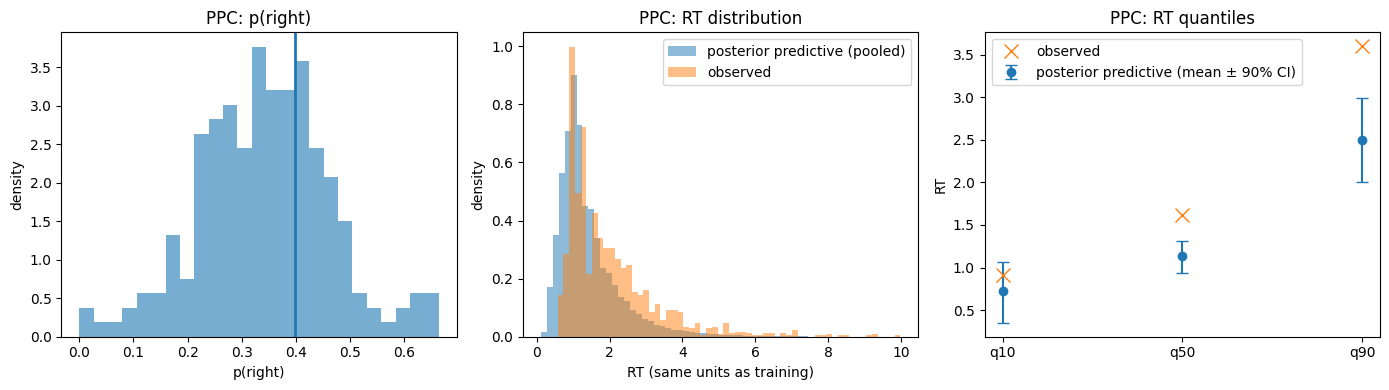

Observed summary: {'n': 1481, 'p_right': 0.39770424365997314, 'rt_q10': 0.9156587719917297, 'rt_q50': 1.6134659051895142, 'rt_q90': 3.6011030673980713}
PPC p(right): mean±sd = 0.34180234209168703 0.12139002280436005
PPC RT q10/q50/q90 mean = [0.7195790127813817, 1.1346840095520019, 2.5034840108156207]


In [11]:
sim_summaries = run_ppc(
    samples=samples,
    x_o_flat=x_o_flat,
    prior_theta=prior_theta,
    saved_cfg=saved_cfg,
    n_ppc=200,          # 100–500 is fine
    device=device,
)

(0.0, 1.0)

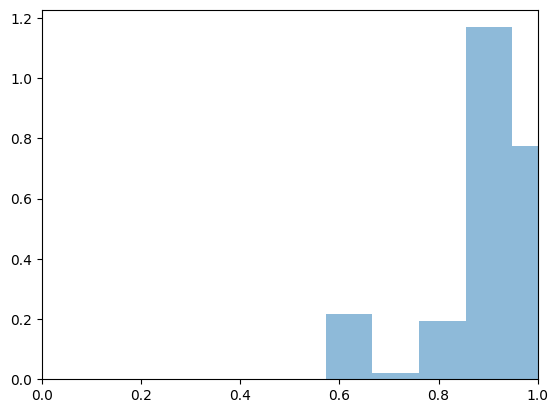

In [18]:
plt.hist(ayla_60_40["rt"].dropna(), bins=100, density=True, alpha=0.5, label="observed")
plt.xlim(0,1)